# Part1


## neural network is basically a massive set of math expressions

In [ ]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
#%pip install graphviz

In [ ]:
def f(x): # a scalar valued function, takes a single scalar x and return a single scalar y
    return 3*x**2 - 4*x+5

In [ ]:
f(3.0)

In [ ]:
# create a set of scale values to feed in
xs = np.arange(-5, 5, 0.25)
# call f on xs to get a set of ys
ys = f(xs)
plt.plot(xs, ys)

In [ ]:
# trying to find the derivative of this function at any single input point x
h = 0.0000001
x = 2/3
(f(x+h) - f(x))/h #(f(x+h) - f(x)): how much the function responded in the positive direction; /h: normalize by the run to get the slope

In [ ]:
# get a bit more complex
a=2.0
b=-3.0
c=10.0
d=a*b+c
print(d)

In [ ]:
# now look at the derivatives of d with respect to a b and c
h = 0.0001

#inputs
a=2.0
b=-3.0
c=10.0


d1=a*b+c
# a += h
# b += h
c += h
d2=a*b+c
print('d1: ', d1)
print('d2: ', d2)
print('slope: ', (d2-d1)/h)

In [ ]:
# start building the "data structure" that maintain the math expressions
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self._backward = lambda: None # for a leaf node there's nothing to do
        self.label = label
        self.grad = 0.0
    def __repr__(self):
        return f"Value(data={self.data})"
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other) # added for part2 in order to make Value[op]Int can work
        out = Value(self.data + other.data, (self,other),'+')
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out
    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self,other),'*')
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out
    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')
        def _backward():
            self.grad += other *(self.data ** (other-1)) * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other): # make sure that Value * int and int * Value can both work
        return self*other
    
    def __truediv__(self, other): # self / other
        return self * other**-1
    
    def __neg__(self): # -self
        return self * -1

    def __sub__(self, other): # self - other
        return self + (-other)

    def __radd__(self, other): # other + self
        return self + other
    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')
        
        def _backward():
            self.grad += out.data * out.grad 
        out._backward = _backward
    
        return out


    def tanh(self):
        x = self.data
        t = (math.exp(2*x)-1)/(math.exp(2*x)+1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        return out
    
    def backward(self):
        # real backpropagataion function here
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()




In [ ]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e+c; d.label = 'd'
f = Value(-2.0, label='f')
L = f*d; L.label='L'


In [ ]:
# a nicer way to visualize the expressions that are being built

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

In [ ]:
draw_dot(L)

the output of the forward pass is -8, now we run back propagation(a recursive use of chain rule), starting with L calculate the derivative with respect to each node 
so we want to see how the change of each node have impact on L

In [ ]:
L = d*f
# dL/dd=? f (f(x+h)-f(x))/h

In [ ]:
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0

In [ ]:
draw_dot(L)

## Chain Rule
If a variable z depends on the variable y, which itself depends on the variable x (that is, y and z are dependent variables), then z depends on x as well, via the intermediate variable y. In this case, the chain rule is expressed as

dz/dx = dz/dy * dy/dx

dL / dc <- what's dd / dc (answer is 1.0)
dd / dc = 1.0 = dd / de
d = c+e

WANT:
dL / dc = (dL / dd) * (dd / dc)

KNOW:
dL / dd
dd / dc

==> c.grad = e.grad = d.grad = -2.0

In [ ]:
c.grad = e.grad = d.grad = -2.0
draw_dot(L)

dL / de = -2.0
e = a * b
de / da ?
dL / da = (dL / de) * (de / da)

In [ ]:
a.grad = -2.0*-3.0
b.grad= -2.0*2.0
draw_dot(L)

iterated through all nodes one by one, locally apply the chain rule

In [ ]:
a.data += 0.01*a.grad
b.data += 0.01*b.grad
c.data += 0.01*c.grad
f.data += 0.01*f.grad

e = a*b
d=e+c
L=d*f

print(L.data)

In [ ]:
def lol(): # verification function
    h = 0.0001

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0, label='f')
    L = f*d; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    b.data += h
    c = Value(10.0, label='c')
    e = a*b; e.label = 'e'
    d = e+c; d.label = 'd'
    f = Value(-2.0 , label='f')
    L = f*d; L.label='L'
    L2 = L.data

    print((L2-L1)/h)
lol()

Another example of manual backpropagation: backpropagate a neuron

In [ ]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid()

## here is the neuron model being used below :

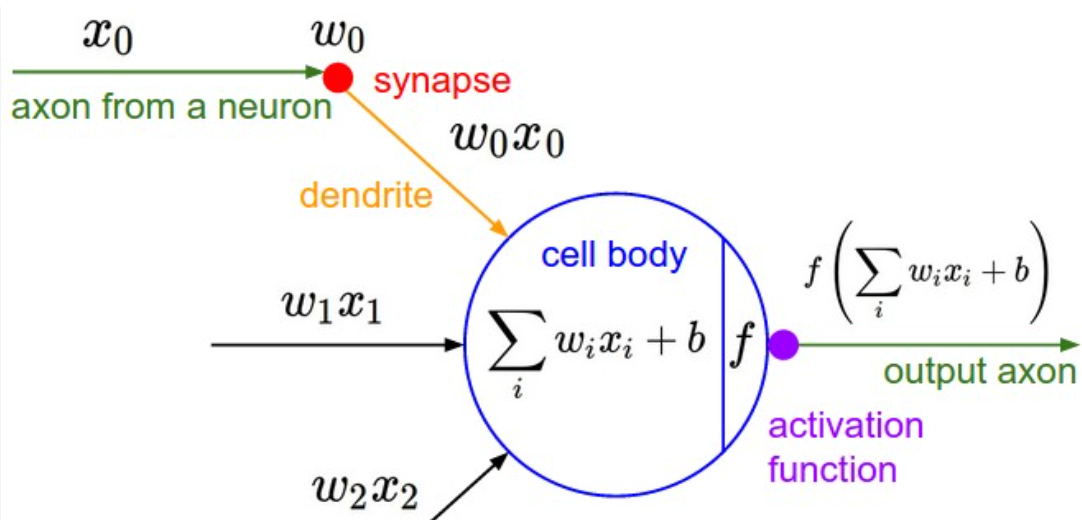

In [ ]:
# inputs x1,x2 create a 2D neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n' # the n here is the cell body above(raw activation without the activation function)
#draw_dot(n)
o = n.tanh(); o.label = 'o'
draw_dot(o)

now start the backpropagation to fill up all the grads

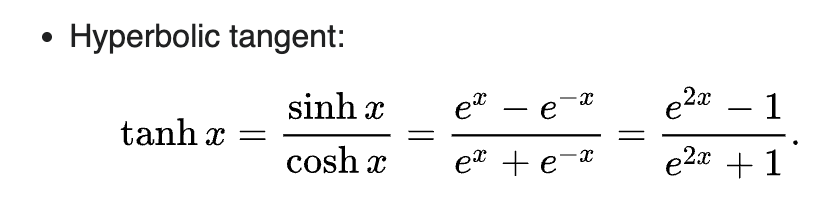 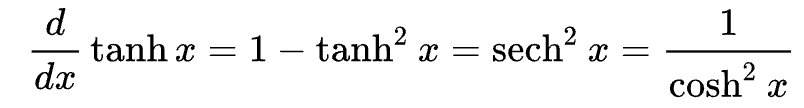

In [ ]:
o.grad = 1.0
draw_dot(o) 

o = tanh(n)
do / dn = 1 - o**2

In [ ]:
1 - o.data**2
n.grad=0.5
x1w1x2w2.grad = 0.5
b.grad=0.5

In [ ]:
x1w1.grad = 0.5
x2w2.grad = 0.5
x2.grad = w2.data * x2w2.grad
w2.grad = x2.data * x2w2.grad
x1.grad = w1.data * x1w1.grad
w1.grad = x1.data * x1w1.grad
draw_dot(o)

In [ ]:
# test of _backward() function instead of input grads manully
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()
draw_dot(o) 

Time to avoid calling _backward() one by one, by using topological sort

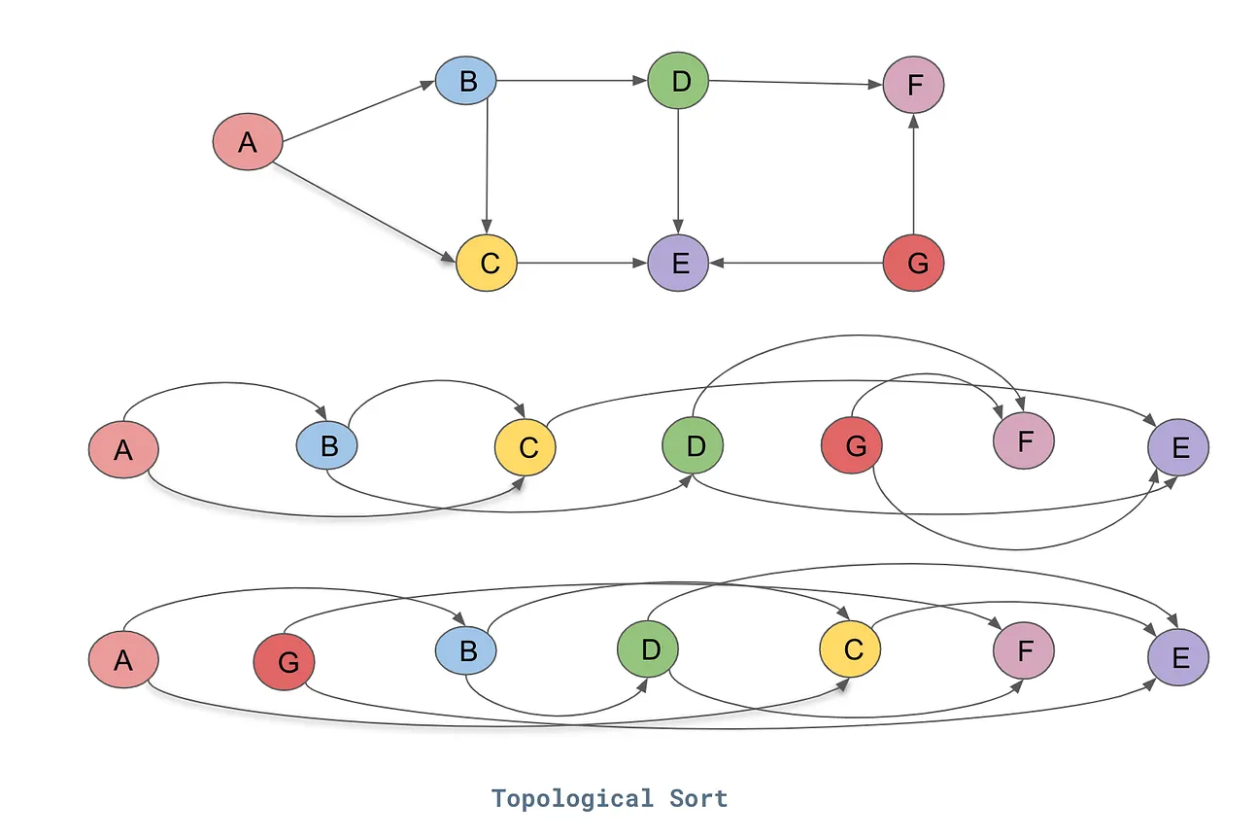

In [ ]:
#function of topological sort
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v._prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

In [ ]:
o.backward()

In [ ]:
draw_dot(o)

Bug testing

In [ ]:
# situation 1 with bugs, same object(a), overwriting
a = Value(3.0, label='a')
b = a + a   ; b.label = 'b'
b.backward()
draw_dot(b)

In [ ]:

#situation 2 with bugs, same variables being used more than once
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b    ; d.label = 'd'
e = a + b    ; e.label = 'e'
f = d * e    ; f.label = 'f'

f.backward()

draw_dot(f)

solution:
    inside def _backward(), instead of self.grad = xxx, we accumulate each time (with +=)

# Part2


break down tanh amd express it as a function of x 

In [ ]:
# inputs x1,x2 create a 2D neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n' # the n here is the cell body above(raw activation without the activation function)
#draw_dot(n)
o = n.tanh(); o.label = 'o'
o.backward()
draw_dot(o)

now breakup the tanh in the graphe above into this expression: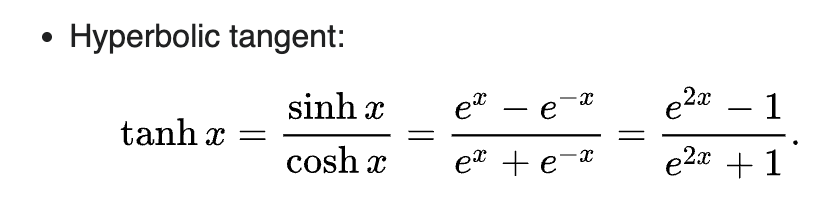

In [ ]:
# inputs x1,x2 create a 2D neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n' 
# --------
e = (2*n).exp()
o = (e-1)/(e+1)
# --------

o.label = 'o'
o.backward()
draw_dot(o)

now use Pytorch do the same thing in a way more efficient way

In [ ]:
#%pip install torch
import torch

In [ ]:

x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

In [ ]:
torch.Tensor([[1,2, 3],[4,5,6]]).double().dtype

In [ ]:
o.item() # o.item() and o.data.item() rpoduce the same result here in PyTorch
o

## start building our neural net -> build out a two-layer multi-layer perceptron(MLP)

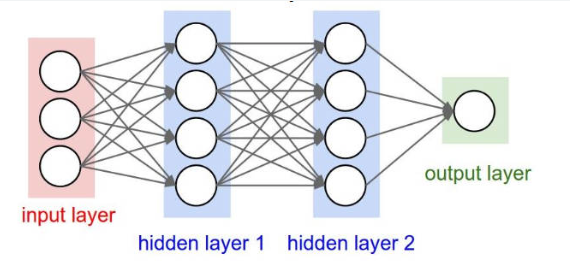

a layer of neuron is a set of neurons evaluated independently

In [ ]:
# start with another single individual neuron that subscribes to the pytorch api
import random

# step 1: build single individual neuron
class Neuron:
    def __init__(self, nin):
      self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
      self.b = Value(random.uniform(-1,1))
    
    def __call__(self,x):
      # w * x + b
      act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
      out = act.tanh()
      return out
    def parameters(self): # to gether all parameters
      return self.w + [self.b]
    
# step 2: define a layer of neurons
class Layer:
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]
  
# step 3: build a MLP
class MLP:
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [ ]:
x=[2.0, 3.0]
#n=Neuron(2)
n=Layer(2, 3)
n(x)

In [ ]:
# build the neural net on the pic above
x=[2.0, 3.0, -1.0]
#n=Neuron(2)
n=MLP(3,[4, 4, 1]) # 3 inputs, 4 neurons for each layer. 1 output
n(x)

In [ ]:
draw_dot(n(x))

In [ ]:
# create a simple data set example
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred # it's normal that the result is far away from the targets, cuz it hasn't been trained yet
# but in general, what we need here is for the result of 1st and 4th input go higher and the rest two go lower

## How to tune the weights to better predict the desired targets?

The trick that is used in DL is to calculate a single number that somehow measures the total performance of your neural network, we call this: single number the loss

In [ ]:
# define a single number that measures how well the nearal network is performing
# for example, for the output above, the loss will be hight cuz it's still far away from the targets
loss = sum((yout - ygt)**2 for ygt,yout in zip(ys, ypred)) #ygt: y ground truth(ground truth is the target)
loss

In [ ]:
# now we need to minimize loss
loss.backward()
n.layers[0].neurons[0].w[0].grad

In [ ]:
draw_dot(loss) # massive graphe

gather up all the parameters of the meural net so that we can operate on all of them simultaneously, for each of them, we'll nudge a tiny amount based on the gradient information.

In [ ]:
len(n.parameters())

In [ ]:
n.layers[0].neurons[0].w[0].data

In [ ]:
#here we nudge all the parameters by tiny amount

for p in n.parameters():
    p.data += -0.01 * p.grad # the gradient vectors are pointing to the direction to where the loss will increase, 
    #so we need to go to the reversed direction(the reason of negative 0.01)
    # 0.01 here is the step size



In [ ]:
n.layers[0].neurons[0].w[0].data 

In [ ]:
# re-calculate the loss after the nudge(new loss a bit smaller than previous one)
# this is the forward pass
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt,yout in zip(ys, ypred)) 
loss

now we need to iterate this process 

In [ ]:
# the process we iterate
# this is gradient descent, by executing this processing multiple times, we can see the loss geting really low
loss.backward()
for p in n.parameters():
    p.data += -0.01 * p.grad
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt,yout in zip(ys, ypred)) 
loss

In [ ]:
ypred

one very good result: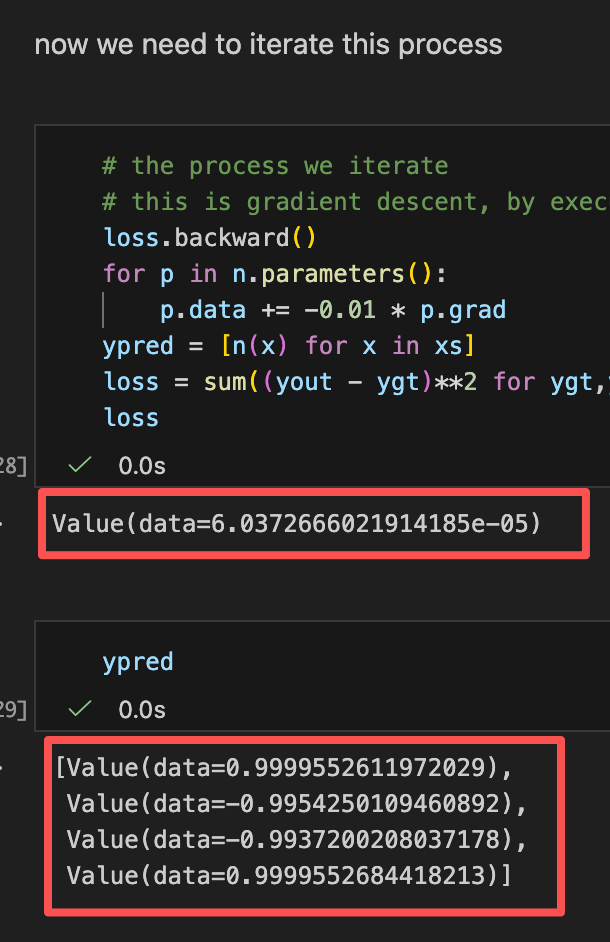

the output of n.parameters() is the setting of weights and biases that make the network predict the desire targets really close
==> We successfully trained a neural network!!!

In [ ]:
n.parameters() 

Now just make the process a bit more respectable and implement an actual training loop:

In [ ]:
# create the data set 
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets


In [ ]:

for k in range(20):
    #forward pass
    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    #gradient descent starts
    #backward pass
    for p in n.parameters(): # this is also called .zero_grad() in pytorch, reseting all the grads to zero before the backward
        p.grad = 0.0
    loss.backward()

    #update
    for p in n.parameters():
        p.data += -0.1*p.grad
    print(k, loss.data)